Here, we demonstrate that the adverserial training removes the relevant categorical information from the bias term:

In [119]:
import os

import pandas as pd
import scanpy as sc
import numpy as np

import torch

from sklearn.metrics import normalized_mutual_info_score
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

In [120]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.preprocess import embed_tf_activity

In [121]:
seed = 888
device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'

In [122]:
n_cores = 20
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

Load the model and associated data:

In [123]:
trainer = io.read_pickled_object(os.path.join(data_path, 'processed', 'Kang_fullbest_trainer.pickle'))
mod = trainer.mod

trainer_na = io.read_pickled_object(os.path.join(data_path, 'processed', 'Kang_no_adverserial_trainer.pickle'))
mod_na = trainer_na.mod


test_cells = open(os.path.join(data_path, 'processed', 'data_split_barcodes', 'kang_test.txt')).read().splitlines()


In [124]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)

adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

In [125]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

First, let's see what the loss looks like across epochs:

In [126]:
train_stats_df = trainer.stats['train'].copy()
train_stats_df_na = trainer_na.stats['train'].copy()

# train_stats_df = train_stats_df.groupby('epoch').mean().reset_index() # delete this

/tmp/ipykernel_4026805/1934334863.py:34: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[0])
/tmp/ipykernel_4026805/1934334863.py:46: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[1])
/tmp/ipykernel_4026805/1934334863.py:60: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[2])
/tmp/ipykernel_4026805/1934334863.py:73: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[3])


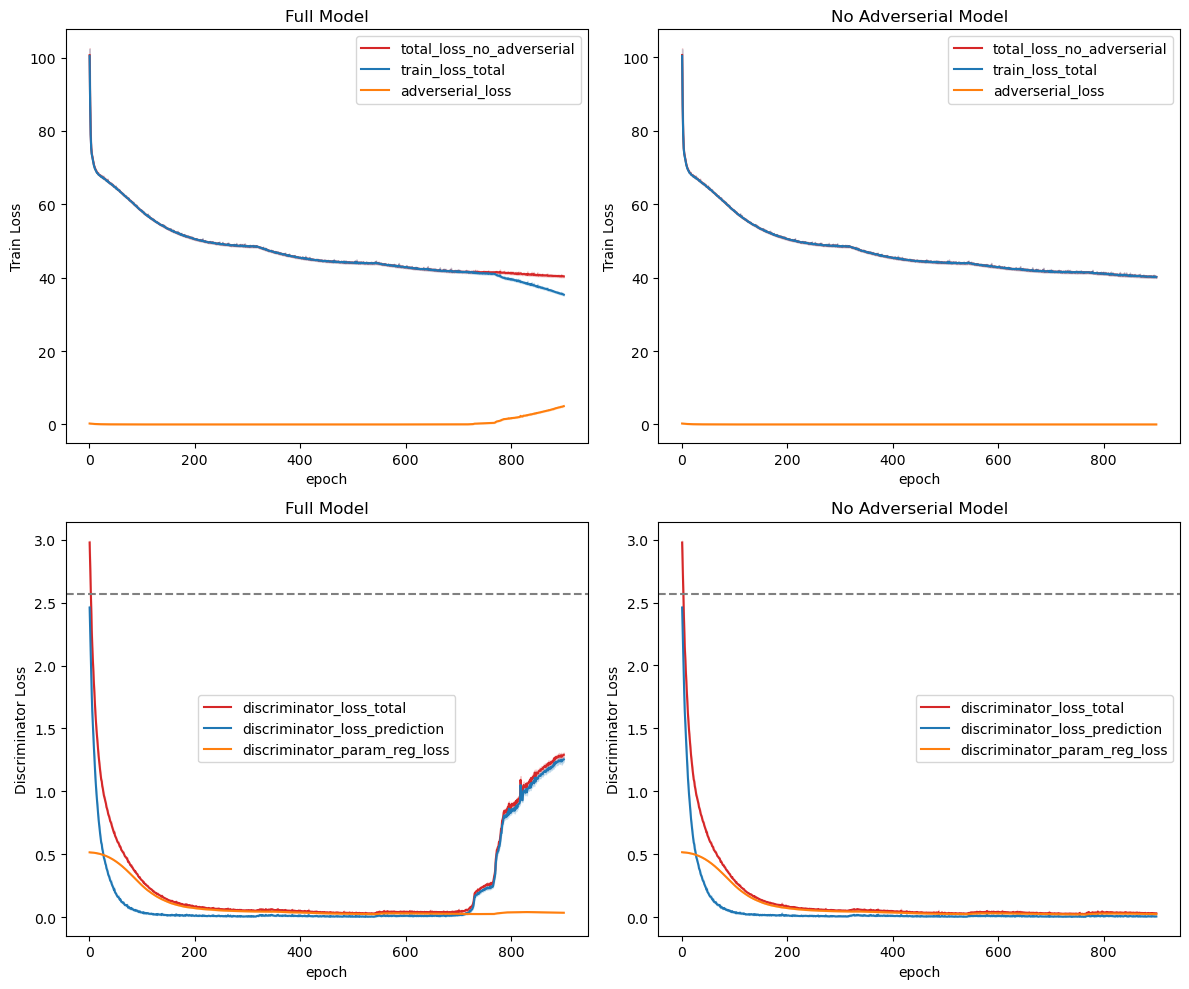

In [12]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (12,10))
ax = ax.flatten()

colors = [
    "#d62728",  # Red
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17a589",  #  Teal 
    "#6baed6",  # light blue
    "#ff9896"   # Light red
]
palette = sns.color_palette(colors)


# Plot 1: full model, adverserial loss
loss_cols_main = [
       'train_loss_prediction', 'sign_reg_loss',
       'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
       'sn_param_reg_loss', 'output_param_reg_loss', 'vae_param_reg_loss', 'kl_divergence']
loss_cols = ['train_loss_total'] + loss_cols_main + ['adverserial_loss']

viz_df = train_stats_df[['epoch'] + loss_cols].copy()
viz_df['total_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
viz_df.drop(columns = loss_cols_main, inplace = True)
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial', 'train_loss_total', 'adverserial_loss'])

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[0])
ax[0].legend(loc='best')#, bbox_to_anchor=(1.05, 0.5))
ax[0].set_ylabel('Train Loss')
ax[0].set_title('Full Model')

# Plot 2: model no adverserial, adverserial loss
viz_df = train_stats_df_na[['epoch'] + loss_cols].copy()
viz_df['total_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
viz_df.drop(columns = loss_cols_main, inplace = True)
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial', 'train_loss_total', 'adverserial_loss'])

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[1])
ax[1].legend(loc='best')#, bbox_to_anchor=(1.05, 0.5))
ax[1].set_ylabel('Train Loss')
ax[1].set_title('No Adverserial Model')


# Plot 3: full model, discriminator loss
loss_cols_disc = ['discriminator_loss_total',
       'discriminator_loss_prediction', 'discriminator_param_reg_loss']

viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[2])
n_cat = trainer.discriminator['discriminators']['seurat_annotations'].classifier[1].fc_layers[0][0].out_features
ax[2].axhline(y=np.log(n_cat), color='gray', linestyle='--')

ax[2].legend(loc='best')
ax[2].set_ylabel('Discriminator Loss')
ax[2].set_title('Full Model')

# Plot 4: model no adverserial, discriminator loss
viz_df = train_stats_df_na[['epoch'] + loss_cols_disc].copy()
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[3])
n_cat = trainer.discriminator['discriminators']['seurat_annotations'].classifier[1].fc_layers[0][0].out_features
ax[3].axhline(y=np.log(n_cat), color='gray', linestyle='--')

ax[3].legend(loc='best')
ax[3].set_ylabel('Discriminator Loss')
ax[3].set_title('No Adverserial Model')


fig.tight_layout()

Next, let's see what the global bias looks like in UMAP space. To do this, we run the following prediction: for each condition (stimulation + cell type), we predict what that cell type would look like in the opposite stimulation condition from ALL the in-distribution data (from all other conditions). 

In [130]:
train_cells = trainer.X_train.index.tolist()
stim_map = {'STIM': 1, 'CTRL': 0}
rev_stim = {'STIM': 'CTRL', 'CTRL': 'STIM'}

cov_idx_map = dict(zip(mod.signaling_network.covariates['seurat_annotations'], 
                       mod.signaling_network.covariates_idx['seurat_annotations']))
cov_rev_map = {v:k for k,v in cov_idx_map.items()}

In [131]:
only_within_celltype = True # only change stim within a cell type
full_expr, full_X, full_covariates = None, None, None

for cond in tf_adata.obs.loc[test_cells, :].condition.unique():
    stim, ct = cond.split('^')

    if only_within_celltype:
        train_cells_cond = tf_adata.obs[(tf_adata.obs['condition'] == rev_stim[stim] + '^' + ct)].index.tolist()
        if len(set(train_cells_cond).difference(train_cells)) != 0:
            raise ValueError('Something went wrong in the counterfactual')
    else:
        train_cells_cond = train_cells
    
    expr_test = mod.df_to_tensor(mod.expr.loc[train_cells_cond, :])

    X_test_df = pd.DataFrame(data = {'IFNB1': [stim_map[stim]]*len(train_cells_cond)})
    X_test = mod.df_to_tensor(X_test_df)

    covariates_idx_test = torch.tensor([cov_idx_map[ct]]*len(train_cells_cond), 
                                       device = mod.device, dtype = torch.int64).view(-1,1)
    
    if full_expr is None:
        full_expr = expr_test
    else: 
        full_expr = torch.cat((full_expr, expr_test), dim = 0)
        
    if full_X is None:
        full_X = X_test
    else: 
        full_X = torch.cat((full_X, X_test), dim = 0)

    if full_covariates is None:
        full_covariates = covariates_idx_test
    else: 
        full_covariates = torch.cat((full_covariates, covariates_idx_test), dim = 0)


In [132]:
mod_na.eval()
with torch.inference_mode():
    y_predicted, Y_full, biases = mod_na(X_in = full_X, covariates_idx = full_covariates, expr = full_expr)
    bias_global_na, bias_mu, bias_log_sigma_squared = biases 

mod.eval()
with torch.inference_mode():
    y_predicted, Y_full, biases = mod(X_in = full_X, covariates_idx = full_covariates, expr = full_expr)
    bias_global, bias_mu, bias_log_sigma_squared = biases
    bias_sigma = torch.exp(bias_log_sigma_squared/2.) + mod.signaling_network.vae.var_min
    
    # add in categorical information
    bias_cats = torch.zeros_like(bias_global.T, device = mod.device, dtype = mod.dtype)
    for cat_group_idx in range(full_covariates.shape[1]):
        cat_group = mod.signaling_network._cat_group_idx[cat_group_idx]
        mod.signaling_network.cat_embeddings[cat_group].weight.data.masked_fill_(mask = mod.signaling_network.cat_embeddings_mask[cat_group], 
                                                                    value = 0.0)
        bias_cats += mod.signaling_network.cat_embeddings[cat_group](full_covariates[:,cat_group_idx]).T
    bias_tot = bias_global.T + bias_cats   

Clustering and dimensionality reduction:

In [133]:
obs = pd.DataFrame(full_covariates.detach().cpu().numpy())
obs.columns = ['seurat_annotations']
obs.seurat_annotations = obs.seurat_annotations.map(cov_rev_map)

# perfect
onehot_df = pd.get_dummies(obs.seurat_annotations).astype(int)
one_hot = sc.AnnData(X = onehot_df, obs = obs)
embed_tf_activity(one_hot, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1, 
                 n_components = one_hot.shape[1] - 1)
# perfectly random
np.random.seed(seed)
rand_idx = np.random.permutation(onehot_df.index)
rand_obs = obs.copy()
rand_obs.index = rand_idx
rand = sc.AnnData(X = onehot_df.loc[rand_idx, :], obs = rand_obs)
embed_tf_activity(rand, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1, 
                 n_components = rand.shape[1] - 1)

# no adverserial
bias_adata_na = sc.AnnData(X = bias_global_na.detach().cpu().numpy(), obs = obs)
embed_tf_activity(bias_adata_na, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1)

# full model
bias_adata = sc.AnnData(X = bias_global.detach().cpu().numpy(), obs = obs)
embed_tf_activity(bias_adata, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1)

# full model -- categorical information added
bias_tot = sc.AnnData(X = bias_tot.detach().cpu().numpy().T, obs = obs)
embed_tf_activity(bias_tot, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1)

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/home/hmbaghda/Projects/scLEMBAS/scLEMBAS/preprocess.py:290: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achi

In [134]:
def adata_dimviz(adata, reduction_type, cat, subset_idx = None):
    viz_df = pd.DataFrame(adata.obsm['X_' + reduction_type])
    viz_df = pd.concat([viz_df, pd.DataFrame(adata.obs[cat]).reset_index(drop = True)], ignore_index = True, axis = 1)

    viz_df.columns = [reduction_type.upper() + str(i+1) for i in range(viz_df.shape[1])]
    viz_df.columns = viz_df.columns[:-1].tolist() + [cat]
    
    if subset_idx is not None:
        viz_df = viz_df.loc[subset_idx, :]
    
    return viz_df

We'll visualize a random subset of 5000 cells because the dataset is large.

In [171]:
adata_types = ['Perfectly Separated', 'Perfectly Mixed', 
                     'Model No Adverserial', 'Model with Adverserial', None, 
              'Model with Adverserial - Categorical Information Added']
adata_dict = dict(zip(adata_types, 
                     [one_hot, rand, bias_adata_na, bias_adata, None, bias_tot]))

The top left panel is clustering/dimreduction results on one-hot encodings of the predicted cell types. The top right panel is this same information, but with the barcodes permuted. These reppresent baseline NMI values from the clustering pipeline. 

''

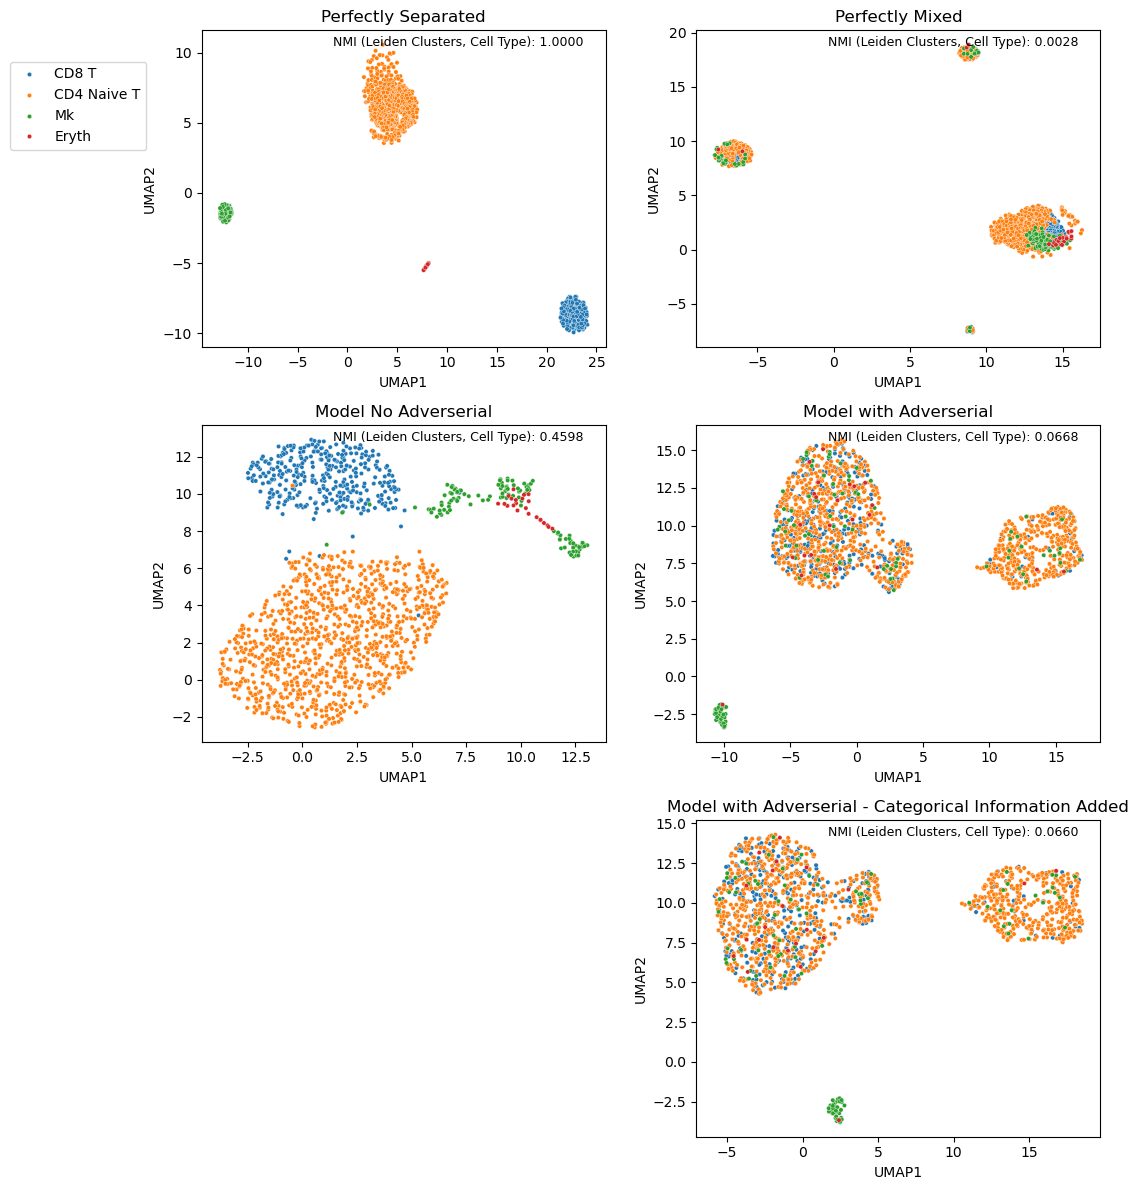

In [172]:
fig, ax = plt.subplots(ncols = 2, nrows = 3, figsize = (10,12))
ax = ax.flatten()

subset_size = None
if subset_size is not None:
    subset_cells = np.random.choice(list(range(y_predicted.shape[0])), size=subset_size, replace=False)
else:
    subset_cells = None

for i, (adata_type, adata) in enumerate(adata_dict.items()):
    if adata is not None:
        viz_df = adata_dimviz(adata = adata, reduction_type = 'umap', cat = 'seurat_annotations', 
                             subset_idx = subset_cells)
        nmi = normalized_mutual_info_score(adata.obs.leiden, adata.obs.seurat_annotations)

        sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = 'seurat_annotations', 
                        s=10,
                        ax = ax[i])
        ax[i].annotate('NMI (Leiden Clusters, Cell Type): {:.4f}'.format(nmi),
                        xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
        ax[i].set_title(adata_type)
    else:
        ax[i].axis('off')

lines, labels = ax[3].get_legend_handles_labels()
fig.legend(lines, labels, loc="upper left", bbox_to_anchor=(-0.125, 0.95))
for ax_ in ax:
    ax_.legend().remove()
fig.tight_layout()
;

Let's also look at the distributions of the values:

In [ ]:
fig, ax = plt.subplots(ncols = 2, nrows = 3, figsize = (10, 11))
ax = ax.flatten()

i = 0
bias_viz = bias_global.detach().cpu().numpy().flatten()
np.random.seed(seed)
bias_viz_sub = np.random.choice(bias_viz, size = int(1e4), replace = False)

counts, bins = np.histogram(bias_viz_sub, bins=30, density=True)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
hist = ax[i].bar(bin_centers, counts, width=(bins[1] - bins[0]), 
          color=sns.color_palette()[0], edgecolor = 'black', label="Sample Distribution")
# sns.histplot(bias_viz_sub, ax = ax[i])

x = np.linspace(-4, 4, 100)
sn, = ax[i].plot(x, stats.norm.pdf(x), 'r--', label="Standard Normal")

ax[i].legend(handles=[hist, sn], labels=["Sample Distribution", "Standard Normal"], 
            loc='upper left', bbox_to_anchor=(-0.7, 1))


ks_statistic, pval = stats.kstest(bias_viz_sub, 'norm')
ax[i].annotate('KS p-value: {:.3f}'.format(pval), 
              xy=(0.05, 0.95), 
            xycoords="axes fraction",
            ha="left")
ax[i].set_title('Global Bias')


i+=1
(q_theoretical, q_sample), _ = stats.probplot(bias_viz_sub, dist="norm")
qq_df = pd.DataFrame({"Theoretical Standard Normal Quantiles": q_theoretical, "Sample Quantiles": q_sample})
sns.scatterplot(data=qq_df, x="Theoretical Standard Normal Quantiles", y="Sample Quantiles", ax = ax[i])
sns.lineplot(x=q_theoretical, y=q_theoretical, color="red", linestyle="--", ax = ax[i])  # 45-degree reference line
ax[i].set_title('Q-Q Plot for Global Bias')

i+=1
bias_viz = bias_cats.detach().cpu().numpy().flatten()
np.random.seed(seed)
bias_viz_sub = np.random.choice(bias_viz, size = int(1e4), replace = False)

counts, bins = np.histogram(bias_viz_sub, bins=30, density=True)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
hist = ax[i].bar(bin_centers, counts, width=(bins[1] - bins[0]), 
          color=sns.color_palette()[0], edgecolor = 'black', label="Sample Distribution")
# sns.histplot(bias_viz_sub, ax = ax[i])

x = np.linspace(-4, 4, 100)
sn, = ax[i].plot(x, stats.norm.pdf(x), 'r--', label="Standard Normal")

# ax[i].legend(handles=[hist, sn], labels=["Sample Distribution", "Standard Normal"], 
#             loc='upper left', bbox_to_anchor=(-0.75, 1))


ks_statistic, pval = stats.kstest(bias_viz_sub, 'norm')
ax[i].annotate('KS p-value: {:.3f}'.format(pval), 
              xy=(0.05, 0.95), 
            xycoords="axes fraction",
            ha="left")
ax[i].set_title('Categorical Bias')

i+=1
(q_theoretical, q_sample), _ = stats.probplot(bias_viz_sub, dist="norm")
qq_df = pd.DataFrame({"Theoretical Standard Normal Quantiles": q_theoretical, "Sample Quantiles": q_sample})
sns.scatterplot(data=qq_df, x="Theoretical Standard Normal Quantiles", y="Sample Quantiles", ax = ax[i])
sns.lineplot(x=q_theoretical, y=q_theoretical, color="red", linestyle="--", ax = ax[i])  # 45-degree reference line
ax[i].set_title('Q-Q Plot for Categorical Bias')


i+=1
bias_viz = bias_mu.detach().cpu().numpy().flatten()
np.random.seed(seed)
bias_viz_sub = np.random.choice(bias_viz, size = int(1e4), replace = False)
sns.kdeplot(bias_viz_sub, ax = ax[i])
ax[i].set_title('Bias Mean')


i+=1
bias_viz = bias_sigma.detach().cpu().numpy().flatten()
np.random.seed(seed)
bias_viz_sub = np.random.choice(bias_viz, size = int(1e4), replace = False)
sns.kdeplot(bias_viz_sub, ax = ax[i])
ax[i].set_title('Bias Variance')

fig.tight_layout()

# To do:

show distribution of these in k-folds